In [1]:
import logging

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
import os


class AdvTransformBase(object):
    """
     Adv Transformer base
    """

    def __init__(self,
                 config_dict={
                 },
                 use_gpu=True,
                 debug=False):
        '''
        '''

        self.config_dict = config_dict
        self.param = None
        self.is_training = False
        self.use_gpu = use_gpu
        self.debug = debug
        self.diff = None
        # by default this is False
        self.is_training = False
        if self.use_gpu:
            self.device = torch.device('cuda')
        else:
            self.device = torch.device('cpu')
        self.init_config(self.config_dict)
        self.param = None
        self.step_size = 1  # step size for optimizing data augmentation

    def init_config(self):
        '''
        initialize a set of transformation configuration parameters
        '''
        if self.debug:
            print('init base class')
        raise NotImplementedError

    def init_parameters(self):
        '''
        initialize transformation parameters
        return random transformaion parameters
        '''
        raise NotImplementedError

    def set_parameters(self, param):
        self.param = param.detach().clone()

    def get_parameters(self):
        return self.param

    def set_step_size(self, step_size=1):
        self.step_size = step_size

    def get_step_size(self):
        return self.step_size

    def train(self):
        self.is_training = True
        self.param = self.param.detach().clone()
        self.param.requires_grad = True

    def eval(self):
        self.param.requires_grad = False
        self.is_training = False

    def rescale_parameters(self):
        raise NotImplementedError

    def optimize_parameters(self, step_size=None):
        raise NotImplementedError

    def forward(self, data):
        '''
        forward the data to get augmented data
        :param data: input images x, N4HW
        :return:
        tensor: augmented images
        '''
        raise NotImplementedError

    def backward(self, data):
        """[warps images back to its  original image coordinates if this is a geometric transformation ]
        Args:
            data ([torch tensor]): [input]
        Raises:
            NotImplementedError: [description]
        """
        raise NotImplementedError

    def predict_forward(self, data):
        """[summary]
        transforms predictions using the corresponding transformation matrix if this is a geometric transformation ]
        Args:
            data ([torch tensor]): [input]
        Returns:
            NotImplementedError: [description]
        """
        raise NotImplementedError

    def predict_backward(self, data):
        """[warps predictions back to its  original image coordinates if this is a geometric transformation ]
        Args:
            data ([torch tensor]): [input]
        Raises:
            NotImplementedError: [description]
        """
        raise NotImplementedError

    def unit_normalize(self, d, p_type='l2'):
        """[summary]
        Performs normalization on batch vectors
        Args:
            d ([torch tensor]): [input vectors]: [NC(D)HW]
            p_type (str, optional): [specify normalization types: 'l1','l2','infinity']. Defaults to 'l2'.
        Returns:
            [type]: [description]
        """
        old_size = d.size()
        d_flatten = d.view(d.size(0), -1)
        if p_type == 'l1':
            norm = d_flatten.norm(p=1, dim=1, keepdim=True)
            d = d_flatten.div(norm.expand_as(d_flatten))
        elif p_type == 'infinity':

            d_abs_max = torch.max(d_flatten, 1, keepdim=True)[
                0].expand_as(d_flatten)
            # print(d_abs_max.size())
            d = d_flatten/(1e-20 + d_abs_max)  # d' =d/d_max

        elif p_type == 'l2':
            l = len(d.shape) - 1
            d_norm = torch.norm(
                d.view(d.shape[0], -1), dim=1).view(-1, *([1]*l))
            d = d / (d_norm + 1e-20)
        return d.view(old_size)

    def rescale_intensity(self, data, new_min=0, new_max=1, eps=1e-20):
        '''
        rescale pytorch batch data
        :param data: N*1*H*W
        :return: data with intensity ranging from 0 to 1
        '''
        bs, c, h, w = data.size(0), data.size(1), data.size(2), data.size(3)
        flatten_data = data.view(bs*c, -1)
        old_max = torch.max(flatten_data, dim=1, keepdim=True).values
        old_min = torch.min(flatten_data, dim=1, keepdim=True).values
        new_data = (flatten_data - old_min+eps) / \
            (old_max - old_min + eps)*(new_max-new_min)+new_min
        new_data = new_data.view(bs, c, h, w)
        return new_data

    def get_name(self):
        '''
        return the name of this transformation
        '''
        raise NotImplementedError

    def is_geometric(self):
        """[summary]
        Returns 1 if this is a geometric transformation, default, 0.
        """
        return 0

    def rescale_parameters(self, param=None):
        if param is None:
            param = self.param
        self.param = param.renorm(p=2, dim=0, maxnorm=self.epsilon)
        return self.param

def get_base_grid(batch_size, image_height, image_width, use_gpu=True):
    '''
    :param batch_size:
    :param image_height:
    :param image_width:
    :param use_gpu:
    :param requires_grad:
    :return:
    grid-wh: 4d grid N*2*H*W
    '''
    # get base grid
    y_ind, x_ind = torch.meshgrid(
        [torch.linspace(-1, 1, image_height), torch.linspace(-1, 1, image_width)])  # image space [0-H]
    x_ind = x_ind.unsqueeze(0).unsqueeze(0)  # 1*1*H*W
    y_ind = y_ind.unsqueeze(0).unsqueeze(0)  # 1*1*H*W
    x_ind = x_ind.repeat(batch_size, 1, 1, 1)  # N*1*H*W
    y_ind = y_ind.repeat(batch_size, 1, 1, 1)
    x_ind.float()
    y_ind.float()
    if use_gpu:
        x_ind = x_ind.cuda()
        y_ind = y_ind.cuda()
    grid_wh = torch.cat((x_ind, y_ind), dim=1)
    return grid_wh


def calculate_image_diff(images):
    """Difference map of the image.
    :param images: 4D tensor, batch of images, [batch,ch,h,w]
    return :
    dx: difference in x-direction: batch*ch*H*W
    dy: difference in y-direction: batch*ch*H*W
    """
    dx = torch.zeros_like(images)
    dy = torch.zeros_like(images)
    # forward difference in first column
    dx[:, :, :, 0] = images[:, :, :, 1] - images[:, :, :, 0]
    dx[:, :, :, -1] = images[:, :, :, -1] - images[:, :, :, -2]
    dx[:, :, :, 1:-1] = 0.5 * (images[:, :, :, 2:] - images[:, :, :, :-2])

    dy[:, :, 0, :] = images[:, :, 1, :] - images[:, :, 0, :]
    dy[:, :, -1, :] = images[:, :, -1, :] - images[:, :, -2, :]
    dy[:, :, 1:-1, :] = 0.5 * (images[:, :, 2:, :] - images[:, :, :-2, :])
    return dx, dy


def calculate_jacobian_determinant(data, type='displacement'):
    '''
    calculate the jacobian determinant over a batch of transformations in pytorch
    :param data: N*2*H*W Input array, changes in x direction: dx: data[:,0]
    :param type: str: 'displacement'
    :return: nd tensor: N*1*H*W determinant of jacobian for transformation
    '''
    type_library = ['displacement']
    assert len(data.size()) == 4 and data.size(
        1) == 2, 'only support 2D version, and transformation format is NCHW'
    assert type in type_library, 'only support {} but found: '.format(
        type_library, type)
    # for each point on the grid, get a 4d tuple [dxx,dyy,dxy,dyx] and calc the determinant using det=(1+dxx)*(1+dyy)-dxy*dyx
    dx = data[:, [0], :, :]
    dy = data[:, [1], :, :]
    dxx, dxy = calculate_image_diff(dx)
    dyx, dyy = calculate_image_diff(dy)

    determinant = (1+dxx)*(1+dyy)-dxy*dyx
    return determinant


def integrate_by_add(basegrid_wh, dxy):
    '''
    transform images with the given deformation fields
    :param basegrid_w:N*1*H*W: horizontal grid
    :param basegrid_H:N*1*H*W: vertical grid
    :param dx: dense deformation in horizontal direction:N*1*H*W
    :param dy: dense deformation in vertical direction:N*1*H*W
    :return:
    new_grid: the input to the torch grid_sample function.
    torch tensor matrix: N*H*W*2:[dx,dy]
    '''

    basegrid_wh += dxy
    # basegrid_wh = torch.clamp(basegrid_wh, -1, 1)
    return basegrid_wh


def vectorFieldExponentiation2D(duv, nb_steps=8, type='ss', use_gpu=True):
    '''
        Computes fast vector field exponentiation as proposed in:
        https://hal.inria.fr/file/index/docid/349600/filename/DiffeoDemons-NeuroImage08-Vercauteren.pdf
        :param duv: velocity field in ,y direction : N*2*H*W,
        :param N: number of steps for integration
        :return:
        integrated deformation field at time point 1: N2HW, [dx,dy]
   '''

    # phi(i/2^n)=x+u(x)
    grid_wh = get_base_grid(batch_size=duv.size(0), image_height=duv.size(2), image_width=duv.size(3),
                            use_gpu=use_gpu)
    duv_interval = duv/(2.0 ** nb_steps)
    phi = integrate_by_add(grid_wh, duv_interval)

    if type == 'ss':
        for i in range(nb_steps):
            # e.g. phi(2^i/2^n) =phi(2^(i-1)/2^n) \circ phi((2^(i-1)/2^n))
            phi = applyComposition2D(phi, phi)
    else:
        # euler integration, here nb_steps becomes exact time steps
        interval_phi = phi
        for i in range(nb_steps):
            # . phi((i+1)/2^n) =phi(1/n) \circ phi(i/n))
            phi = applyComposition2D(interval_phi, phi)
    # get the offset flow
    phi = phi-grid_wh
    return phi


def applyComposition2D(flow1, flow2):
    """
    Compose two deformation fields using linear interpolation.
    :param flow1 [f]::N*2*H*W, [dx,dy] A->B, the left is the 'static' deformation
    :param flow2 [g]:N*2*H*W  [dx,dy] B->C, the right is the 'delta' deformation
    :return:
    flow_field/deformation field h= g(f(x)):A->C, [dx,dy], N*2*H*W
    """
    interpolated_f1 = F.grid_sample(flow1, flow2.permute(
        0, 2, 3, 1), padding_mode='border', align_corners=True)  # NCHW
    return interpolated_f1


class AdvMorph(AdvTransformBase):
    """
     Adv Morph
    """

    def __init__(self,
                 config_dict={'epsilon': 1.5,
                              'data_size': [10, 1, 8, 8],
                              'vector_size': [4, 4],
                              'interpolator_mode': 'bilinear'
                              },
                 power_iteration=False,
                 use_gpu: bool = True, debug: bool = False):
        '''
        '''
        super(AdvMorph, self).__init__(
            config_dict=config_dict, use_gpu=use_gpu, debug=debug)
        self.align_corners = True
        # in the original demons paper, the sigma for gaussian smoothing is recommended to set to 1.
        self.sigma = 1
        self.gaussian_ks = 3
        self.smooth_iter = 1
        self.num_steps = 8  # internal steps for scaling and squaring intergration
        self.interpolator_mode = 'bilinear'
        self.integration_type = 'ss'
        self.param = None
        self.power_iteration = power_iteration

    def init_config(self, config_dict):
        '''
        initialize a set of transformation configuration parameters
        '''
        self.epsilon = config_dict['epsilon']
        self.xi = 0.5
        self.data_size = config_dict['data_size']
        self.vector_size = config_dict['vector_size']
        self.interpolator_mode = config_dict['interpolator_mode']

    def init_parameters(self):
        '''
        initialize transformation parameters
        return random transformaion parameters
        '''
        self.init_config(self.config_dict)
        self.base_grid_wh = get_base_grid(
            batch_size=self.data_size[0], image_height=self.data_size[2], image_width=self.data_size[3], use_gpu=self.use_gpu)

        vector = self.init_velocity(
            batch_size=self.data_size[0],  height=self.vector_size[0], width=self.vector_size[1], use_zero=False)
        self.param = vector
        if self.debug:
            print('init velocity:', vector.size())
        return vector

    def forward(self, data, interpolation_mode=None):
        '''
        forward the data to get transformed data
        :param data: input images x, N4HW
        :return:
        tensor: transformed images
        '''
        if self.debug:
            print('apply morphological transformation')
        if self.param is None:
            self.param = self.init_parameters()
        if interpolation_mode is None:
            interpolation_mode = self.interpolator_mode
        if self.power_iteration and self.is_training:
            dxy, displacement = self.get_deformation_displacement_field(
                duv=self.xi*self.param)
        else:
            dxy, displacement = self.get_deformation_displacement_field(
                duv=self.epsilon*self.param)
        transformed_image = self.transform(data, dxy, mode=interpolation_mode)

        self.diff = transformed_image-data
        self.displacement = displacement
      
        return transformed_image

    def backward(self, data, interpolation_mode=None):
        '''
        backward image
        '''
        if interpolation_mode is None:
            interpolation_mode = self.interpolator_mode
        if self.power_iteration and self.is_training:
            dxy, displacement = self.get_deformation_displacement_field(
                duv=-self.xi*self.param)
        else:
            dxy, displacement = self.get_deformation_displacement_field(
                duv=-self.epsilon*self.param)
        transformed_image = self.transform(
            data, dxy, mode=self.interpolator_mode)
        if self.debug:
            logging.info('warp back.')
        return transformed_image

    def predict_forward(self, data):
        return self.forward(data)

    def predict_backward(self, data):
        return self.backward(data)

    def get_deformation_displacement_field(self, duv=None):
        if duv is None:
            duv = self.param
        dxy = self.DemonsCompose(
            duv=duv, init_deformation_dxy=self.base_grid_wh, smooth=True)
        disp = dxy.permute(0, 2, 3, 1)-self.base_grid_wh.permute(0, 2, 3, 1)
        return dxy, disp

    def init_velocity(self, batch_size, height, width, use_zero=False):
        '''
        :param batch_size:
        :param height:
        :param width:
        :param use_zero: initialize with zero values
        :return:
        nd tensor: N*2*H*W, a velocity field/offset field with values between -1 and 1.
        '''
        # offsets = offsets.cuda()

        if not use_zero:
            duv = (torch.rand(batch_size, 2, height, width,
                              device=self.device, dtype=torch.float32)*2-1)
            duv =self.unit_normalize(duv)
        else:
            duv = torch.zeros(batch_size, 2, height, width,
                              device=self.device, dtype=torch.float32)

        return duv

    def gaussian_smooth(self, inputvector, iter=1, kernel_size=41, sigma=8):
        '''
        apply gaussian smooth functions to deformation field to avoid unrealistic and too aggressive deformations
        :param input: NCHW
        :param iter: max number of iterations, avoid infinestimal.
        :return: smoothed deformation
        '''
        n_channel = inputvector.size(1)
        gaussian_conv = self.get_gaussian_kernel(
            kernel_size=kernel_size, sigma=sigma, channels=n_channel)
        for i in range(iter):
            inputvector = gaussian_conv(inputvector)
        return inputvector

    def get_gaussian_kernel(self, kernel_size=5, sigma=8, channels=3):
        # Create a x, y coordinate grid of shape (kernel_size, kernel_size, 2)
        # Use n_sd sigmas
        if kernel_size < 2 * int(3.5 * sigma) + 1:
            # odd size so padding results in correct output size
            kernel_size = 2 * int(3.5 * sigma) + 1

        x_coord = torch.arange(kernel_size)
        x_grid = x_coord.repeat(kernel_size).view(kernel_size, kernel_size)
        y_grid = x_grid.t()
        xy_grid = torch.stack([x_grid, y_grid], dim=-1).float()

        mean = (kernel_size - 1) / 2.
        variance = sigma ** 2.

        # Calculate the 2-dimensional gaussian kernel which is
        # the product of two gaussian distributions for two different
        # variables (in this case called x and y)
        gaussian_kernel = (1. / (2. * math.pi * variance)) * \
            torch.exp(
            -torch.sum((xy_grid - mean) ** 2., dim=-1) /
            (2 * variance)
        )

        # Make sure sum of values in gaussian kernel equals 1.
        gaussian_kernel = gaussian_kernel / torch.sum(gaussian_kernel)

        # Reshape to 2d depthwise convolutional weight
        gaussian_kernel = gaussian_kernel.view(1, 1, kernel_size, kernel_size)
        gaussian_kernel = gaussian_kernel.repeat(channels, 1, 1, 1)
        pad_size = kernel_size // 2
        gaussian_filter = nn.Conv2d(in_channels=channels, out_channels=channels,
                                    kernel_size=kernel_size, groups=channels, dilation=1, stride=1, bias=False,
                                    padding=pad_size)

        gaussian_filter.weight.data = gaussian_kernel
        gaussian_filter.weight.data = gaussian_kernel
        gaussian_filter.weight.requires_grad = False
        if self.use_gpu:
            gaussian_filter = gaussian_filter.cuda()
        return gaussian_filter

    def DemonsCompose(self, duv, init_deformation_dxy, smooth=False):
        '''
        :param duv: velocity field
        :param init_deformation_dxy:
        :return:
        new composed_deformation_grid N*2*H*W
        '''
        duv = self.gaussian_smooth(
            duv, iter=self.smooth_iter, kernel_size=self.gaussian_ks, sigma=self.sigma)
        duv = F.interpolate(duv, size=(self.base_grid_wh.size(
            2), self.base_grid_wh.size(3)), mode='bilinear', align_corners=False)

        integrated_offsets = vectorFieldExponentiation2D(duv=duv, nb_steps=self.num_steps,
                                                         type=self.integration_type)

        if integrated_offsets.size(2) != self.base_grid_wh.size(2) or integrated_offsets.size(3) != self.base_grid_wh.size(3):
            integrated_offsets = F.interpolate(integrated_offsets, size=(self.base_grid_wh.size(
                2), self.base_grid_wh.size(3)), mode='bilinear', align_corners=False)

        # update deformation with composition
        composed_deformation_grid = applyComposition2D(
            init_deformation_dxy, integrated_offsets + self.base_grid_wh)
        # smooth
        if smooth:
            smoothed_offset = self.gaussian_smooth(composed_deformation_grid - self.base_grid_wh, sigma=self.sigma,
                                                   kernel_size=self.gaussian_ks, iter=1)
            composed_deformation_grid = smoothed_offset + self.base_grid_wh
        composed_deformation_grid = torch.clamp(
            composed_deformation_grid, -1, 1)
        return composed_deformation_grid

    def train(self):
        self.is_training = True
        if self.param is None:
            self.init_parameters()
        if self.power_iteration:
            self.param = self.unit_normalize(self.param)
        self.param = torch.nn.Parameter(self.param, requires_grad=True)

    def optimize_parameters(self, step_size=None):
        if step_size is None:
            self.step_size = step_size
        if self.debug:
            logging.info('optimize morph')
        if self.power_iteration:
            duv = self.unit_normalize(self.param.grad)
            param = duv.detach()
        else:
            duv = self.unit_normalize(self.param.grad)
            param = self.param+step_size*duv.detach()
        self.param = param.detach()
        return self.param
    
    def rescale_parameters(self,param=None):
        if param is None:
            param =self.param
        self.param =self.unit_normalize(param)
        return self.param

    def transform(self, data, deformation_dxy, mode='bilinear', padding_mode='border'):
        '''
        transform images with the given deformation fields
        :param data: input data, N*C*H*W
        :param deformation_dxy: deformation N*2*H*W
        :return:
        transformed data: torch tensor matrix: N*ch*H*W
        deformed_grid: torch tensor matrix: N*H*W*2
        offsets: N*H*W*2
        '''
        grid_tensor = deformation_dxy.permute(0, 2, 3, 1)  # N*H*W*2
        # transform images
        transformed_image = F.grid_sample(
            data, grid_tensor, mode=mode, align_corners=self.align_corners)
        # gen flow field
        return transformed_image

    def get_name(self):
        return 'morph'

    def is_geometric(self):
        return 1


def check_dir(dir_path, create=False):
    '''
    check the existence of a dir, when create is True, will create the dir if it does not exist.
    dir_path: str.
    create: bool
    return:
    exists (1) or not (-1)
    '''
    if os.path.exists(dir_path):
        return 1
    else:
        if create:
            os.makedirs(dir_path)
        return -1


input: tensor([[[[0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.5000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.5000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.5000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.5000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.5000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.5000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.5000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.5000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.5000, 0.0000, 0.00

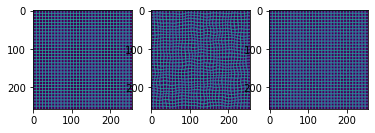

In [5]:

if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from os.path import join as join
    # from advchain.common.utils import check_dir
    dir_path = './log'
    check_dir(dir_path, create=True)
    images = torch.zeros((4, 1, 256, 256)).float().cuda()
    images[:, :, ::8, :] = 0.5
    images[:, :, :, ::8] = 0.5

    print('input:', images)
    augmentor = AdvMorph(config_dict={'epsilon': 1.5,
                                      'xi': 0.5,
                                      'data_size': [4, 1, 256, 256],
                                      'vector_size': [256//8, 256//8],
                                      'interpolator_mode': 'bilinear'
                                      },

                         debug=True, use_gpu=True)
    augmentor.init_parameters()
    transformed = augmentor.forward(images.cuda())
    recovered = augmentor.backward(transformed)
    error = recovered-images
    print('sum error', torch.sum(error))

    plt.subplot(131)
    plt.imshow(images.cpu().numpy()[0, 0])

    plt.subplot(132)
    plt.imshow(transformed.cpu().numpy()[0, 0])

    plt.subplot(133)
    plt.imshow(recovered.cpu().numpy()[0, 0])

    plt.savefig(join(dir_path, 'test_morph.png'))